# Práctica guiada: Procesamiento digital de imágenes

Esta práctica funciona como puente entre los cuadernos conceptuales y el laboratorio aplicado. La propuesta es que completes código, pruebes variantes y expliques con tus palabras qué decisiones tomaste.

## Objetivos

- Recuperar ideas de color, canales, bordes e intensidad.
- Practicar lectura de imágenes con `OpenCV`.
- Resolver consignas breves con andamiaje.
- Prepararte para el laboratorio de segmentación y la actividad integradora.


In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import skimage as ski


def mostrar_imagenes(imagenes, titulos, cmap=None, figsize=(14, 4)):
    fig, axes = plt.subplots(1, len(imagenes), figsize=figsize)
    if len(imagenes) == 1:
        axes = [axes]

    for ax, imagen, titulo in zip(axes, imagenes, titulos):
        if imagen.ndim == 2:
            ax.imshow(imagen, cmap=cmap or "gray")
        else:
            ax.imshow(imagen)
        ax.set_title(titulo)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def segmentar_por_umbral(imagen, umbral):
    mascara = np.zeros_like(imagen, dtype=np.uint8)
    mascara[imagen > umbral] = 255
    return mascara


In [2]:
base = Path(".")

cv2.imwrite(str(base / "paisaje.png"), cv2.cvtColor(ski.data.astronaut(), cv2.COLOR_RGB2BGR))
cv2.imwrite(str(base / "texto.png"), ski.data.page())
cv2.imwrite(str(base / "monedas.png"), ski.data.coins())

print("Archivos de práctica listos: paisaje.png, texto.png y monedas.png")


Archivos de práctica listos: paisaje.png, texto.png y monedas.png


## Ejercicio 1: Color y canales

Completá los pasos.

1. Cargá `paisaje.png` con `OpenCV`.
2. Convertí la imagen a `RGB`.
3. Extraé los tres canales.
4. Mostrá la imagen original y los canales por separado.
5. Escribí una observación breve sobre qué zonas se destacan en cada canal.


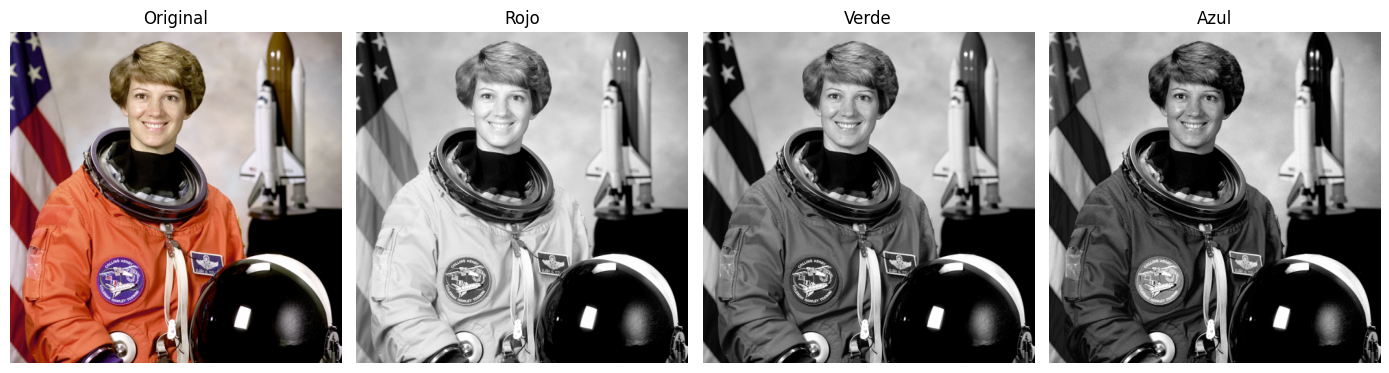

In [5]:
# 1. Cargar la imagen
img_bgr = cv2.imread("paisaje.png")

# 2. Convertirla a RGB
# img_rgb = ...

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


# 3. Extraer canales
# canal_rojo = ...
# canal_verde = ...
# canal_azul = ...


canal_rojo = img_rgb[:, :, 0]
canal_verde = img_rgb[:, :, 1]
canal_azul = img_rgb[:, :, 2]

# 4. Visualizar resultados
mostrar_imagenes(
    [img_rgb, canal_rojo, canal_verde, canal_azul],
    ["Original", "Rojo", "Verde", "Azul"],
)


In [12]:
# Escribí acá tu observación sobre los canales.

# ¿Qué zonas aparecen más brillantes en cada uno?
'''
CANAL ROJO: Zona Brillante sobre rostro y fondo
CANAL VERDE: Zona brillante parte del rostro cabello y en zona espejadas (casco)
CANAL AZUL: Zona brillante presente en las pates claras'''

observacion_canales = "CANAL ROJO: es el canal màs claro, no muestra contraste en los valores cercanos al 0 en la escala de grises " 
"\nCANAL VERDE: sube la intensidad del color, muestra mayo contraste" 
"\nCANAL AZUL: canal más intenso y oscuro, se puede observar una mayo definiciòn en los detalles por el contraste que presenta"
print(observacion_canales)


CANAL ROJO: es el canal màs claro, no muestra contraste en los valores cercanos al 0 en la escala de grises 
CANAL VERDE: sube la intensidad del color, muestra mayo contraste
CANAL AZUL: canal más intenso y oscuro, se puede observar una mayo definiciòn en los detalles por el contraste que presenta


## Ejercicio 2: Recorte y redimensionado

1. Definí una región de interés de `100 x 100` píxeles dentro de `paisaje.png`.
2. Redimensioná ese recorte a `220 x 220` píxeles.
3. Armá un mosaico `2 x 2` con el recorte redimensionado.
4. Explicá, con una frase, la diferencia entre recortar y redimensionar.


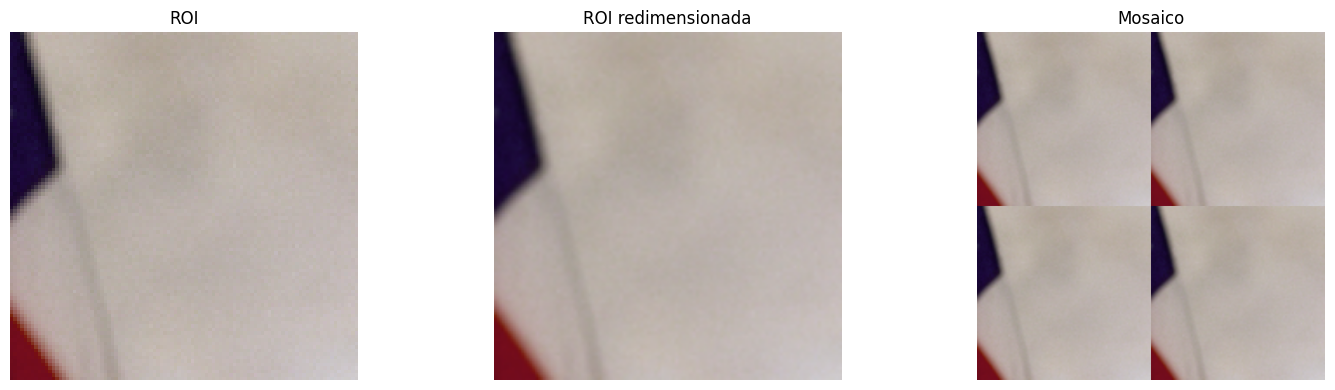

In [ ]:
# Definí los índices de tu región de interés.
y1, y2 = 100, 100
x1, x2 = 220, 220

roi = img_rgb[y1:y2, x1:x2]
roi_grande = cv2.resize(roi, (220, 220))

# Armá un mosaico 2 x 2.
fila_superior = ...
fila_inferior = ...
mosaico = ...

mostrar_imagenes(
    [roi, roi_grande, mosaico],
    ["ROI", "ROI redimensionada", "Mosaico"],
    figsize=(15, 4),
)


In [ ]:
# Explicación breve.
explicacion_geometria = ""
print(explicacion_geometria)


## Ejercicio 3: Bordes y umbralización

1. Cargá `texto.png` en escala de grises.
2. Aplicá `Canny` con dos pares de umbrales distintos.
3. Cargá `monedas.png` en escala de grises.
4. Segmentá la imagen de monedas con al menos dos umbrales.
5. Compará los resultados y explicá cuál te parece más útil.


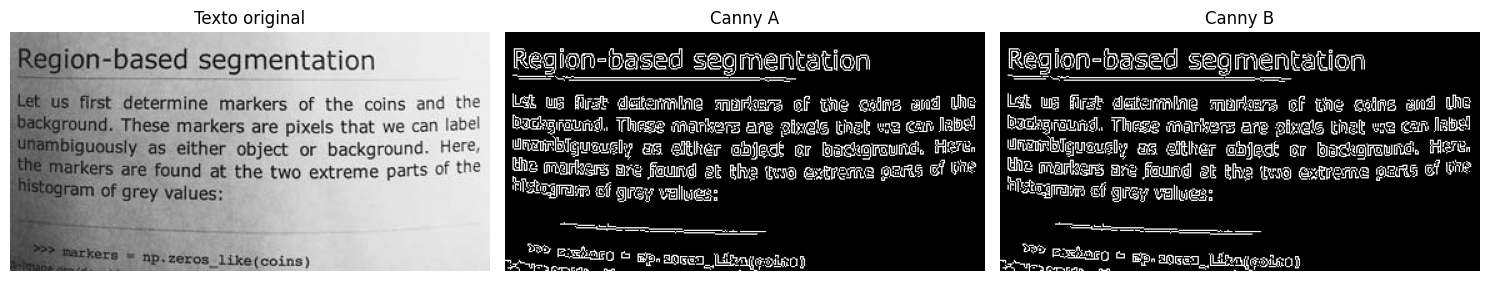

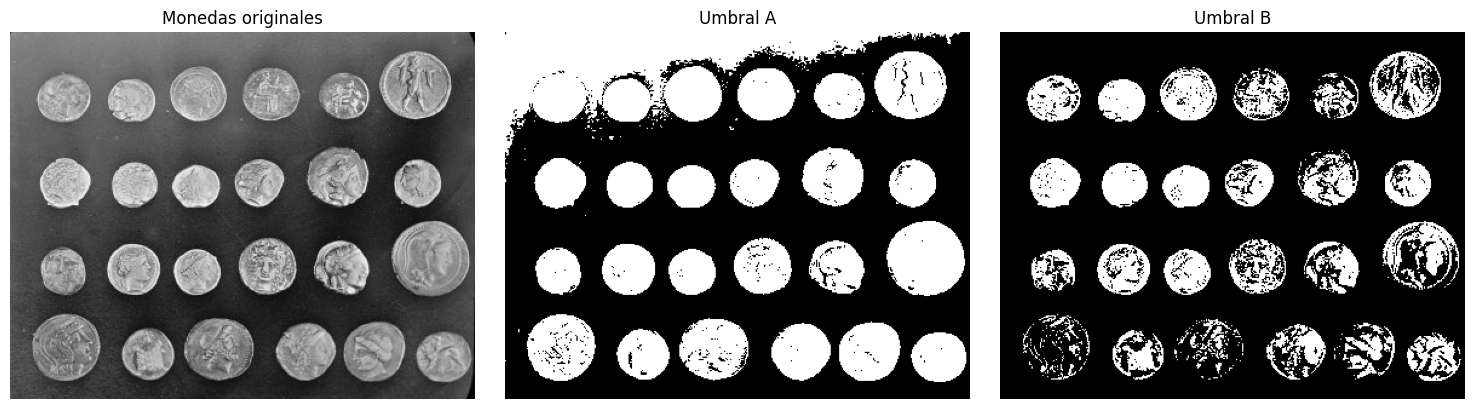

In [14]:
img_texto = cv2.imread("texto.png", cv2.IMREAD_GRAYSCALE)

canny_a = cv2.Canny(img_texto, 80, 140)
canny_b = cv2.Canny(img_texto, 80, 140)


mostrar_imagenes(
    [img_texto, canny_a, canny_b],
    ["Texto original", "Canny A", "Canny B"],
    figsize=(15, 4),
)

img_monedas = cv2.imread("monedas.png", cv2.IMREAD_GRAYSCALE)

seg_a = segmentar_por_umbral(img_monedas, 100)
seg_b = segmentar_por_umbral(img_monedas, 150)

mostrar_imagenes(
    [img_monedas, seg_a, seg_b],
    ["Monedas originales", "Umbral A", "Umbral B"],
    figsize=(15, 4),
)


## Cierre breve

Antes de pasar al laboratorio, revisá si podés responder estas preguntas:

- ¿cuándo conviene mirar canales por separado?
- ¿qué cambia al modificar los umbrales de `Canny`?
- ¿por qué una segmentación por umbral puede funcionar bien en una imagen y mal en otra?

Si todavía dudás en alguna, volvé a los cuadernos anteriores y recuperá las ideas centrales.
